In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:13pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

In [2]:
import pandas as pd #파일 입력(read_excel), 교차표(crosstab), 원핫인코딩(get_dummies)
import numpy as np
from sklearn.model_selection import train_test_split #훈련셋과 시험셋 분리 함수
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential, save_model, load_model

# 과적합을 줄이기 위한 방법 : dropout, 배치정규화, L2정규화
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2


# 데이터 불균형 극복 5.5 : 4.5 → 5:5
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pylab as plt # 모델 학습과정 살펴보기
from sklearn.metrics import confusion_matrix # 혼동행렬

- age: 나이 (년 단위)
- sex: 성별 (1 = 남성, 0 = 여성)
- cp (Chest Pain Type): 흉통의 유형 (0~3 값, 일반 협심증부터 무증상까지 분류)
- trestbps: 안정 시 혈압 (mmHg)
- chol: 혈청 콜레스테롤 수치 (mg/dl)
- fbs (Fasting Blood Sugar): 공복 혈당이 120 mg/dl 초과인지 여부 (1 = 참, 0 = 거짓)
- restecg: 안정 시 심전도(ECG) 결과 (0~2)
- thalach: 운동 시 달성한 최대 심박수
- exang: 운동 유발 협심증 여부 (1 = 있음, 0 = 없음)
- oldpeak: 휴식기에 비해 운동 시 나타나는 ST 부위 하강(ST depression) 정도
- slope: 최고 운동 시 ST 세그먼트의 기울기ca: 형광투시법으로 색칠된 주요 혈관 수 (0~3개)
- thal: 지중해빈혈 등 혈액 질환 여부 (정상, 고정 결함, 가역적 결함 등)
- target (Diagnosis): 심장질환 진단 결과 (0 = 정상, 1 = 심장질환 있음)

# 이진분류(로지스틱 회귀분석)
1. 데이터셋 생성 & 전처리
    * 엑셀 → 데이터프레임 → ?처리(결측치로 전환하여 결측치처리) →  X, y분리
      → X변수의 scale조정 → train_test_split()을 이용하여 학습셋과 테스트셋을 분리

2. 모델 생성(입력13, 타겟1) & 학습과정설정 & 학습
3. 모델 평가(그래프, 평가, 혼동행렬 = 교차표)
4. 모델 사용

# 1. 데이터 셋 생성 & 전처리

In [3]:
df = pd.read_excel('data/heart-disease.xlsx',
                  # sheet_name = 'processed.cleveland'
                  )
df.head()

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [4]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [5]:
df.isin(['?']).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [6]:
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [7]:
# 방법 1 : ? 가 있는 행을 삭제
drop_idx = df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?')].index
df = df.drop(drop_idx)

In [8]:
# 방법 2 : ?를 결측치로 대체 => 결측치 삭제
df = df.replace('?', np.nan)
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [9]:
# 결측치가 포함된 데이터 추출
df[df['chol'].isna() | df['ca'].isna() | df['hsl'].isna()]
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [10]:
# 결측치 처리 : 삭체(dropna) cf. fillna() apply()
df.dropna(how='any', inplace=True) # 결측치가 한역이라도 있으면 삭제
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [11]:
df.isna().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [7]:
df.shape

(296, 14)

In [12]:
# 타겟변수 분포가 균형적인지
df['heartDisease'].value_counts()/df.shape[0]

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [13]:
df['heartDisease'].value_counts(normalize=True)

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [14]:
# X, y분리 → x변수의 scale조정
X = df.iloc[:, :-1].values #맨 마지막 열을 제외한 부분을 numpy배열
y = df.iloc[:, -1:].to_numpy() # 2차원 numpy배열
X.shape, y.shape

((296, 13), (296, 1))

In [15]:
# X변수의 scale조정
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
print('원 데이터 :', X[0])
print('스케일 조정 데이터 :', scaled_X[0])

원 데이터 : [63 1 1 145 233 1 2 150 0 2.3 3 0 6]
스케일 조정 데이터 : [0.70833333 1.         0.         0.48113208 0.24429224 1.
 1.         0.60305344 0.         0.37096774 1.         0.
 0.75      ]


In [16]:
# scaled_x와 y를 학습데이터셋 : 테스트셋 = 8:2
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                                    y,
                                                    #train_size=0.8
                                                    test_size=0.2,
                                                    random_state=7,# seed값
                                                   stratify=y #층화추출
                                                   )

In [17]:
# 심장병 음성 / 양성 비율(y, y_train, y_test)
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.542373
1    0.457627
dtype: float64
0    0.533333
1    0.466667
dtype: float64


In [18]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((236, 13), (236, 1), (60, 13), (60, 1))

# 2. 모델생성 & 학습과정 설정 & 학습
- 모델 : 13 → 32 → 16 → 8 → 1
- 학습과정을 시각화한 그래프를 보고 과적합 줄이기
- 과적합 줄이기 위한 방법
    * dropout : 학습할 때마다 일부 뉴런을 랜덤하게 끄기. 특정 뉴런 조합에 과하게 의존하는 것을 막아준다.
    * BatchNomalization(배치 정규화) : 각 층의 출력을 정규화해서 더 안정적이고 빠르게 수렴하도록 도움.
    * L2 정규화(규제) : 가중치가 너무 커지지 않게 학습과정에서 미리 누름. 가중치가 크면 입력값이 살짝 바뀌어도 출력이 확 바뀜. 규제를 세게(0.01) / 규제 중간(0.001) / 규제 약하게(0.0001)
    

In [50]:
model = Sequential()
model.add(Dense(units=32, input_dim=13, activation='relu', 
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화
model.add(Dropout(0.4))         # 40%를 랜덤하게 꺼서 과적합 방지
model.add(Dense(units=16, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units=8, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
# Dense층 뒤에 배치정규화층에서의 파라미터 : Dense층(32) 출력갯수 * 4
    # ggamma(스케일)           - 32(학습O)
    # beta(이동)               - 32 (학습O)
    # moving_mean(이동평균)     - 32(학습X)
    # moving_variance(이동분산) - 32(학습X)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 32)                448       
                                                                 
 batch_normalization_6 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_6 (Dropout)         (None, 32)                0         
                                                                 
 dense_9 (Dense)             (None, 16)                528       
                                                                 
 batch_normalization_7 (Batc  (None, 16)               64        
 hNormalization)                                                 
                                                                 
 dropout_7 (Dropout)         (None, 16)               

In [51]:
# 학습과정 설정
from tensorflow.keras.metrics import Recall, Precision, Accuracy
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer='adam',
             # optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy', # Accuracy(name='accracy')
                      Recall(name='recall'),        # 재현율(실제값 중심=1을 얼마나 잘 예측했는지)
                      Precision(name='precision')]) # 정밀도(예측값 중심=1이라고 예측한 것 중 얼마나 1인지)

In [53]:
# 클래스(0/1) 가중치 계산 (55:45 정도의 비율 → 50:50)
from sklearn.utils.class_weight import compute_class_weight
y_train_flat = y_train.flatten() # y_train.reshape(-1)
class_weight = compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_train_flat),
                y = y_train_flat)
print('class_weight :', class_weight)
class_weight_dict = dict(enumerate(class_weight))
print('학습시 가중치 조정값 :', class_weight_dict)
# y_train의 빈도수(0은?개, 1은 ?개)
values, counts = np.unique(y_train_flat, return_counts=True)
print('빈도수 :', dict(zip(values, counts)))
print(counts[0]*class_weight_dict[0], counts[1]*class_weight_dict[1])

# 빈도 분포
ratios = counts / counts.sum()
print(ratios[0]*class_weight_dict[0], ratios[1]*class_weight_dict[1])


class_weight : [0.921875   1.09259259]
학습시 가중치 조정값 : {0: 0.921875, 1: 1.0925925925925926}
빈도수 : {0: 128, 1: 108}
118.0 118.0
0.5 0.5


In [68]:
# callback 설정
# ReduceLROnPlateau : 성능이 정체되면  학습률(learing_rate)을 낮춰서 세밀하게 탐색
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                             factor=0.5, # 학습률을 원학습률의 절반으로
                             patience=7, # 7번 연속 개선이 없으면
                             min_lr=1e-6 # 학습률의 최소값 10의 -6승이하로는 안 내려가게 
                             )

In [70]:
# 학습
hist = model.fit(X_train, y_train, # 학습데이터
                epochs=200, # 학습횟수
                validation_split=0.2, # 학습데이터에서 20%를 검증데이터로 사용 
                class_weight=class_weight_dict, # loss계산시 얼마나 더 중요하게 취급될지의 가중치 
                callbacks=[reduce_lr],
                verbose=2)

Epoch 1/200
6/6 - 1s - loss: 0.1888 - accuracy: 0.9362 - recall: 0.9425 - precision: 0.9213 - val_loss: 0.0882 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 0.0010 - 1s/epoch - 171ms/step
Epoch 2/200
6/6 - 0s - loss: 0.2671 - accuracy: 0.8830 - recall: 0.8736 - precision: 0.8736 - val_loss: 0.0879 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 0.0010 - 239ms/epoch - 40ms/step
Epoch 3/200
6/6 - 0s - loss: 0.2113 - accuracy: 0.9255 - recall: 0.9425 - precision: 0.9011 - val_loss: 0.0878 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 0.0010 - 191ms/epoch - 32ms/step
Epoch 4/200
6/6 - 0s - loss: 0.2283 - accuracy: 0.9043 - recall: 0.9080 - precision: 0.8876 - val_loss: 0.0881 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 0.0010 - 199ms/epoch - 33ms/step
Epoch 5/200
6/6 - 0s - loss: 0.1785 - accuracy: 0.9574 - recall: 0.9425 - precision: 0.9647 - val_loss: 0.0885 - val_accuracy: 1.0

Epoch 38/200
6/6 - 0s - loss: 0.2320 - accuracy: 0.9149 - recall: 0.9195 - precision: 0.8989 - val_loss: 0.0947 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 6.2500e-05 - 196ms/epoch - 33ms/step
Epoch 39/200
6/6 - 0s - loss: 0.2450 - accuracy: 0.8883 - recall: 0.8851 - precision: 0.8750 - val_loss: 0.0952 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 3.1250e-05 - 191ms/epoch - 32ms/step
Epoch 40/200
6/6 - 0s - loss: 0.1966 - accuracy: 0.9096 - recall: 0.9195 - precision: 0.8889 - val_loss: 0.0948 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 3.1250e-05 - 201ms/epoch - 33ms/step
Epoch 41/200
6/6 - 0s - loss: 0.2495 - accuracy: 0.9043 - recall: 0.8966 - precision: 0.8966 - val_loss: 0.0944 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 3.1250e-05 - 205ms/epoch - 34ms/step
Epoch 42/200
6/6 - 0s - loss: 0.2318 - accuracy: 0.9149 - recall: 0.9195 - precision: 0.8989 - val_loss: 0.0

Epoch 75/200
6/6 - 0s - loss: 0.2154 - accuracy: 0.9043 - recall: 0.9195 - precision: 0.8791 - val_loss: 0.0953 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 202ms/epoch - 34ms/step
Epoch 76/200
6/6 - 0s - loss: 0.2116 - accuracy: 0.9149 - recall: 0.9195 - precision: 0.8989 - val_loss: 0.0961 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 202ms/epoch - 34ms/step
Epoch 77/200
6/6 - 0s - loss: 0.2149 - accuracy: 0.9309 - recall: 0.9425 - precision: 0.9111 - val_loss: 0.0955 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 197ms/epoch - 33ms/step
Epoch 78/200
6/6 - 0s - loss: 0.2477 - accuracy: 0.9309 - recall: 0.9540 - precision: 0.9022 - val_loss: 0.0957 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 195ms/epoch - 32ms/step
Epoch 79/200
6/6 - 0s - loss: 0.2164 - accuracy: 0.9309 - recall: 0.9425 - precision: 0.9111 - val_loss: 0.0

Epoch 112/200
6/6 - 0s - loss: 0.2019 - accuracy: 0.9255 - recall: 0.9195 - precision: 0.9195 - val_loss: 0.0959 - val_accuracy: 0.9792 - val_recall: 1.0000 - val_precision: 0.9545 - lr: 1.0000e-06 - 216ms/epoch - 36ms/step
Epoch 113/200
6/6 - 0s - loss: 0.3195 - accuracy: 0.8511 - recall: 0.8851 - precision: 0.8105 - val_loss: 0.0952 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 230ms/epoch - 38ms/step
Epoch 114/200
6/6 - 0s - loss: 0.1723 - accuracy: 0.9574 - recall: 0.9885 - precision: 0.9247 - val_loss: 0.0946 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 226ms/epoch - 38ms/step
Epoch 115/200
6/6 - 0s - loss: 0.2269 - accuracy: 0.9202 - recall: 0.9195 - precision: 0.9091 - val_loss: 0.0946 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 208ms/epoch - 35ms/step
Epoch 116/200
6/6 - 0s - loss: 0.2736 - accuracy: 0.8777 - recall: 0.9195 - precision: 0.8333 - val_loss

Epoch 149/200
6/6 - 0s - loss: 0.1824 - accuracy: 0.9362 - recall: 0.9540 - precision: 0.9121 - val_loss: 0.0946 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 201ms/epoch - 33ms/step
Epoch 150/200
6/6 - 0s - loss: 0.2281 - accuracy: 0.9096 - recall: 0.9195 - precision: 0.8889 - val_loss: 0.0943 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 224ms/epoch - 37ms/step
Epoch 151/200
6/6 - 0s - loss: 0.2270 - accuracy: 0.9043 - recall: 0.8966 - precision: 0.8966 - val_loss: 0.0946 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 220ms/epoch - 37ms/step
Epoch 152/200
6/6 - 0s - loss: 0.2336 - accuracy: 0.9096 - recall: 0.9080 - precision: 0.8977 - val_loss: 0.0940 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 200ms/epoch - 33ms/step
Epoch 153/200
6/6 - 0s - loss: 0.2242 - accuracy: 0.9255 - recall: 0.9425 - precision: 0.9011 - val_loss

Epoch 186/200
6/6 - 0s - loss: 0.2580 - accuracy: 0.8936 - recall: 0.9655 - precision: 0.8317 - val_loss: 0.0925 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 194ms/epoch - 32ms/step
Epoch 187/200
6/6 - 0s - loss: 0.2016 - accuracy: 0.9415 - recall: 0.9770 - precision: 0.9043 - val_loss: 0.0921 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 218ms/epoch - 36ms/step
Epoch 188/200
6/6 - 0s - loss: 0.2344 - accuracy: 0.9202 - recall: 0.9310 - precision: 0.9000 - val_loss: 0.0924 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 190ms/epoch - 32ms/step
Epoch 189/200
6/6 - 0s - loss: 0.2605 - accuracy: 0.9096 - recall: 0.9195 - precision: 0.8889 - val_loss: 0.0923 - val_accuracy: 1.0000 - val_recall: 1.0000 - val_precision: 1.0000 - lr: 1.0000e-06 - 203ms/epoch - 34ms/step
Epoch 190/200
6/6 - 0s - loss: 0.1753 - accuracy: 0.9255 - recall: 0.9310 - precision: 0.9101 - val_loss

# 3. 모델 평가(그래프, 평가, 교차표)

In [71]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision', 'lr'])

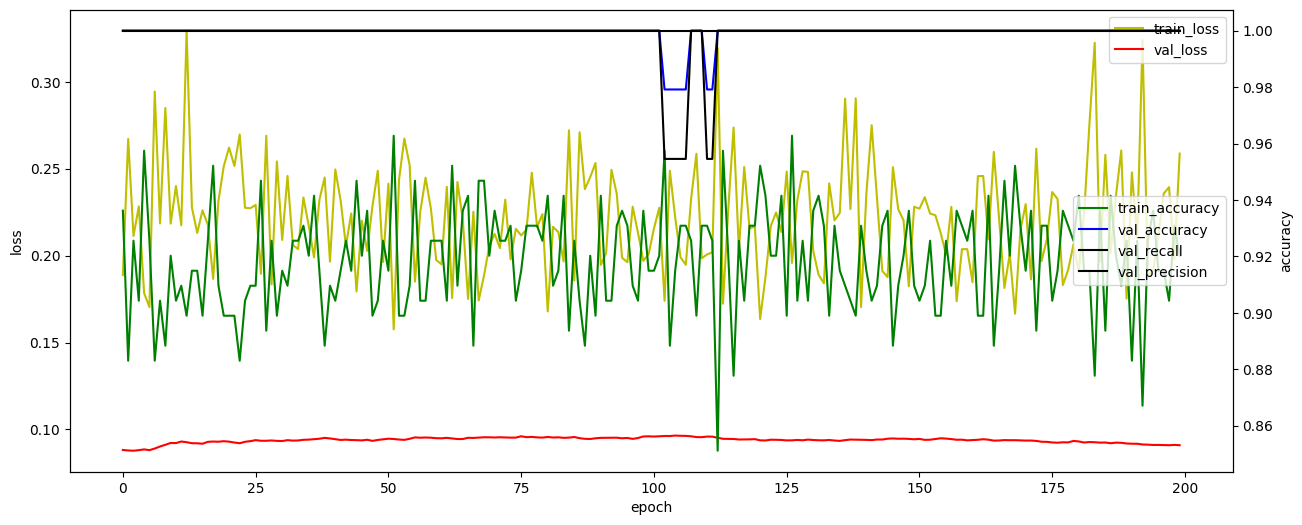

In [76]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_recall') # recall(검정)
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision') # precision(검정)

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [73]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f'model loss : {score[0]}')
print(f'model accuracy : {score[1]*100:.2f}%')
print(f'model recall : {score[2]*100:.2f}%')
print(f'model precision : {score[3]*100:.2f}%')

model loss : 0.4715632200241089
model accuracy : 83.33%
model recall : 89.29%
model precision : 78.12%


In [74]:
# 교차표(혼동행렬)
y_test.reshape(-1)

array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

# 4. 모델 사용
- 저장 / 예측

In [77]:
# 딥러닝 모델 저장시 확장자 : h5, keras
model.save('model/06.h5')
save_model(model, 'model/06.h5')
model = load_model('model/06.h5')

In [78]:
data = [[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6]]
input_data = scaler.transform(data)
(model.predict(input_data)>0.5).astype(int)

1/1 [==============================] - 0s 230ms/step


array([[0]])

# 분류분석
1. 데이터셋 생성 & 전처리
    * X_train, y_train, X_test, y_test → y_train과 y_test 원핫인코딩
2. 모델생성 & 학습과정 설정 & 모델 학습
3. 모델평가(학습과정 시각화, 평가, 교차표 argmax이용)
4. 모델사용(저장및 예측)

## 1. 데이터셋 생성 & 전처리
- y_train, y_test 원핫인코딩

```
  0 → 1 0
  1 → 0 1
```  

In [81]:
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((236, 13), (236, 2), (60, 13), (60, 2))

## 2. 모델생성 & 학습과정 설정 & 학습

In [82]:
model = Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu', 
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화
model.add(Dropout(0.4))         # 40%를 랜덤하게 꺼서 과적합 방지
model.add(Dense(units=16, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units=8, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units=2, activation='softmax')) #분류분석의 출력층의 활성화함수
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_9 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_9 (Dropout)         (None, 32)                0         
                                                                 
 dense_13 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_10 (Bat  (None, 16)               64        
 chNormalization)                                                
                                                                 
 dropout_10 (Dropout)        (None, 16)                0

In [83]:
model.compile(loss="categorical_crossentropy",
              #optimizer=Adom(learning_rate=0.001),
              optimizer='adam',
              metrics=['accuracy', Recall(name='recall'), Precision(name='precision')]              
             )

In [84]:
%%time
hist = model.fit(X_train, Y_train,
                 epochs=200,
                 validation_split=0.2,
                 class_weight=class_weight_dict,
                 callbacks=[reduce_lr],
                 verbose=1)

Epoch 1/200
6/6 [==============================] - 4s 169ms/step - loss: 0.8718 - accuracy: 0.5851 - recall: 0.5851 - precision: 0.5851 - val_loss: 0.7420 - val_accuracy: 0.4375 - val_recall: 0.4375 - val_precision: 0.4375 - lr: 0.0010
Epoch 2/200
6/6 [==============================] - 0s 44ms/step - loss: 0.9215 - accuracy: 0.5691 - recall: 0.5691 - precision: 0.5691 - val_loss: 0.7330 - val_accuracy: 0.5208 - val_recall: 0.5208 - val_precision: 0.5208 - lr: 0.0010
Epoch 3/200
6/6 [==============================] - 0s 42ms/step - loss: 0.7870 - accuracy: 0.6543 - recall: 0.6543 - precision: 0.6543 - val_loss: 0.7249 - val_accuracy: 0.5208 - val_recall: 0.5208 - val_precision: 0.5208 - lr: 0.0010
Epoch 4/200
6/6 [==============================] - 0s 39ms/step - loss: 0.8254 - accuracy: 0.6011 - recall: 0.6011 - precision: 0.6011 - val_loss: 0.7145 - val_accuracy: 0.5417 - val_recall: 0.5417 - val_precision: 0.5417 - lr: 0.0010
Epoch 5/200
6/6 [==============================] - 0s 38ms/

Epoch 36/200
6/6 [==============================] - 0s 37ms/step - loss: 0.5451 - accuracy: 0.7553 - recall: 0.7553 - precision: 0.7553 - val_loss: 0.5124 - val_accuracy: 0.7292 - val_recall: 0.7292 - val_precision: 0.7292 - lr: 0.0010
Epoch 37/200
6/6 [==============================] - 0s 38ms/step - loss: 0.5157 - accuracy: 0.7819 - recall: 0.7819 - precision: 0.7819 - val_loss: 0.5093 - val_accuracy: 0.7292 - val_recall: 0.7292 - val_precision: 0.7292 - lr: 0.0010
Epoch 38/200
6/6 [==============================] - 0s 37ms/step - loss: 0.5722 - accuracy: 0.7713 - recall: 0.7713 - precision: 0.7713 - val_loss: 0.5061 - val_accuracy: 0.7500 - val_recall: 0.7500 - val_precision: 0.7500 - lr: 0.0010
Epoch 39/200
6/6 [==============================] - 0s 37ms/step - loss: 0.5495 - accuracy: 0.7500 - recall: 0.7500 - precision: 0.7500 - val_loss: 0.5025 - val_accuracy: 0.7500 - val_recall: 0.7500 - val_precision: 0.7500 - lr: 0.0010
Epoch 40/200
6/6 [==============================] - 0s 3

Epoch 71/200
6/6 [==============================] - 0s 36ms/step - loss: 0.4864 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4690 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010
Epoch 72/200
6/6 [==============================] - 0s 37ms/step - loss: 0.5163 - accuracy: 0.8032 - recall: 0.8032 - precision: 0.8032 - val_loss: 0.4685 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010
Epoch 73/200
6/6 [==============================] - 0s 41ms/step - loss: 0.4828 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.4676 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010
Epoch 74/200
6/6 [==============================] - 0s 39ms/step - loss: 0.4779 - accuracy: 0.7926 - recall: 0.7926 - precision: 0.7926 - val_loss: 0.4669 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010
Epoch 75/200
6/6 [==============================] - 0s 3

6/6 [==============================] - 0s 37ms/step - loss: 0.4472 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4791 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 2.5000e-04
Epoch 106/200
6/6 [==============================] - 0s 37ms/step - loss: 0.4673 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4799 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.2500e-04
Epoch 107/200
6/6 [==============================] - 0s 39ms/step - loss: 0.4579 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4806 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.2500e-04
Epoch 108/200
6/6 [==============================] - 0s 35ms/step - loss: 0.4942 - accuracy: 0.7766 - recall: 0.7766 - precision: 0.7766 - val_loss: 0.4811 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.2500e-04
Epoch 109/200
6/6 [==============================]

6/6 [==============================] - 0s 37ms/step - loss: 0.5087 - accuracy: 0.7979 - recall: 0.7979 - precision: 0.7979 - val_loss: 0.4929 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 7.8125e-06
Epoch 140/200
6/6 [==============================] - 0s 39ms/step - loss: 0.5438 - accuracy: 0.7872 - recall: 0.7872 - precision: 0.7872 - val_loss: 0.4932 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 7.8125e-06
Epoch 141/200
6/6 [==============================] - 0s 38ms/step - loss: 0.4023 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4932 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 3.9063e-06
Epoch 142/200
6/6 [==============================] - 0s 38ms/step - loss: 0.4663 - accuracy: 0.8351 - recall: 0.8351 - precision: 0.8351 - val_loss: 0.4934 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 3.9063e-06
Epoch 143/200
6/6 [==============================]

6/6 [==============================] - 0s 39ms/step - loss: 0.4903 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4960 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 174/200
6/6 [==============================] - 0s 39ms/step - loss: 0.5148 - accuracy: 0.8032 - recall: 0.8032 - precision: 0.8032 - val_loss: 0.4956 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 175/200
6/6 [==============================] - 0s 38ms/step - loss: 0.4055 - accuracy: 0.8777 - recall: 0.8777 - precision: 0.8777 - val_loss: 0.4958 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 176/200
6/6 [==============================] - 0s 45ms/step - loss: 0.5018 - accuracy: 0.7926 - recall: 0.7926 - precision: 0.7926 - val_loss: 0.4962 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 177/200
6/6 [==============================]

## 3. 모델 평가(시각화, 평가, 교차표)

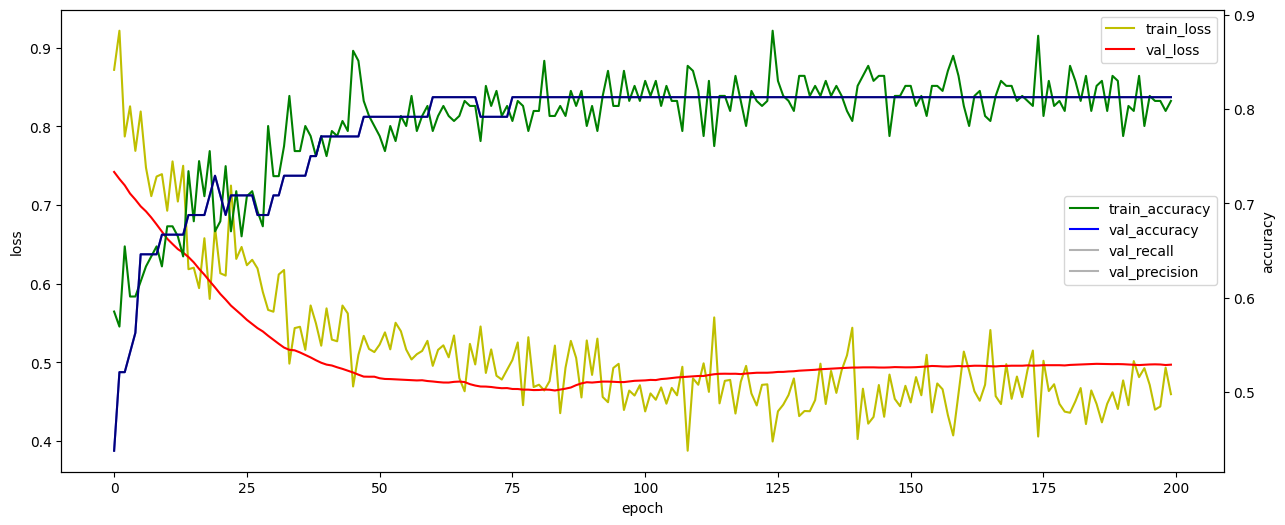

In [86]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_recall', alpha=0.3) # recall(검정)
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision', alpha=0.3) # precision(검정)

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox)
acc_ax.legend(loc='center right')
plt.show()

In [87]:
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test, verbose=0)
print('model loss :', loss)
print(f'model accuracy : {accuracy*100:.2f}%')
print(f'model precision : {accuracy*100:.2f}%')
print(f'model recall : {accuracy*100:.2f}%')

model loss : 0.4258682131767273
model accuracy : 86.67%
model precision : 86.67%
model recall : 86.67%


In [90]:
# 교차표
Y_test.argmax(axis=1)
y_test.reshape(-1)
y_train.flatten()

array([0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0], dtype=int64)

In [93]:
# 예측값
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

2/2 [==============================] - 0s 10ms/step


array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [94]:
pd.crosstab(y_test.reshape(-1), y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0,28,4
1,4,24


In [95]:
confusion_matrix(y_test, y_hat)

array([[28,  4],
       [ 4, 24]], dtype=int64)

## 4. 모델 사용
- 저장 / 예측

In [96]:
model.save('model/06.h5')
save_model(model, 'model/06.h5')
model2 = load_model('model/06.h5')

In [99]:
data = [[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6],
       [67, 1, 4, 160, 286, 0, 0, 108, 1, 1.5, 2, 3, 3]]
input_data = scaler.transform(data)
model.predict(input_data)#.argmax(axis=1)

1/1 [==============================] - 0s 46ms/step


array([[0.7091668 , 0.2908332 ],
       [0.0336327 , 0.96636724]], dtype=float32)

array([[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6],
       [67, 1, 4, 160, 286, 0, 0, 108, 1, 1.5, 2, 3, 3]], dtype=object)